## Import Libraries

In [21]:
!pip install seaborn  


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [22]:
!pip install torch 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Add parent directory to path to import model
sys.path.insert(0, os.path.abspath('../..'))
from src.models.cnn import SeismicCNN, CompactSeismicCNN
from src.data.preprocessing import DataAugmentation

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set up plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("\n✓ Libraries imported successfully!")

Using device: cpu

✓ Libraries imported successfully!


## Load Labeled Data

Load the windowed seismograms and labels created by the labeling notebooks.

**Data Sources:**
- **AK Network**: High-quality professional seismic data (Alaska Seismic Network)
- **Catalog (AM)**: Raspberry Shake citizen science data with verified earthquake catalog
- **Rule-based**: Rule-based labeling from multi-class labeling notebook

In [24]:
# =============================================================================
# DATA SOURCE SELECTION
# Options: 'ak', 'catalog', or 'rule_based'
#   - 'ak': High-quality AK network data (professional seismic stations)
#   - 'catalog': AM network (Raspberry Shake) with verified earthquake catalog
#   - 'rule_based': Rule-based labeled data
# =============================================================================
DATA_SOURCE = 'ak'  # <-- CHANGE THIS: 'ak', 'catalog', or 'rule_based'

data_dir = Path("../02_labeling/labeled_data")

if not data_dir.exists():
    raise FileNotFoundError(f"Data directory '{data_dir}' not found. Run labeling notebooks first.")

# Find available data files based on selected source
if DATA_SOURCE == 'ak':
    # Use AK network data (high-quality professional seismic data)
    waveform_files = sorted(data_dir.glob("AK_waveforms_*.npy"))
    label_files = sorted(data_dir.glob("AK_labels_*.npy"))
    metadata_files = sorted(data_dir.glob("AK_metadata_*.csv"))
    data_source_name = "AK NETWORK (High-Quality Professional Seismic Data)"
elif DATA_SOURCE == 'catalog':
    # Use earthquake catalog data (AM/Raspberry Shake with verified ground truth)
    waveform_files = sorted(data_dir.glob("catalog_waveforms_*.npy"))
    label_files = sorted(data_dir.glob("catalog_labels_*.npy"))
    metadata_files = sorted(data_dir.glob("catalog_metadata_*.csv"))
    data_source_name = "CATALOG (AM Network - Raspberry Shake with Verified Catalog)"
else:
    # Use rule-based labeled data
    waveform_files = sorted(data_dir.glob("windowed_waveforms_*.npy"))
    label_files = sorted(data_dir.glob("labels_*.npy"))
    metadata_files = sorted(data_dir.glob("metadata_*.csv"))
    data_source_name = "RULE-BASED LABELING"

if not waveform_files or not label_files:
    raise FileNotFoundError(f"No {DATA_SOURCE} data found. Run the appropriate labeling notebook first:\n"
                          f"  - For AK data: run download_AK_only_data.ipynb\n"
                          f"  - For catalog data: run download_earthquake_catalog.ipynb\n"
                          f"  - For rule-based: run multi_class_labeling.ipynb")

# Use most recent files
waveforms_file = waveform_files[-1]
labels_file = label_files[-1]
metadata_file = metadata_files[-1] if metadata_files else None

print(f"=" * 70)
print(f"DATA SOURCE: {data_source_name}")
print(f"=" * 70)
print(f"\nLoading data from:")
print(f"  Waveforms: {waveforms_file.name}")
print(f"  Labels: {labels_file.name}")
if metadata_file:
    print(f"  Metadata: {metadata_file.name}")

# Load data
X = np.load(waveforms_file)  # Shape: (n_samples, window_length)
y = np.load(labels_file)     # Shape: (n_samples,)

if metadata_file:
    metadata = pd.read_csv(metadata_file)
else:
    metadata = None

print(f"\n✓ Data loaded successfully!")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

# Print class distribution
class_names = ['Noise', 'Traffic', 'Earthquake']
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  {class_names[int(label)]} (class {int(label)}): {count} samples ({count/len(y)*100:.1f}%)")

# Show additional info for catalog/AK data
if DATA_SOURCE in ['ak', 'catalog'] and metadata is not None:
    print(f"\nDataset diversity:")
    print(f"  Unique earthquakes: {metadata['event_id'].nunique()}")
    print(f"  Unique stations: {metadata['station'].nunique()}")
    if 'network' in metadata.columns:
        print(f"  Network: {metadata['network'].unique().tolist()}")
    if 'channel' in metadata.columns:
        print(f"  Channels: {metadata['channel'].unique().tolist()}")
    print(f"  Magnitude range: M{metadata['magnitude'].min():.1f} - M{metadata['magnitude'].max():.1f}")

DATA SOURCE: AK NETWORK (High-Quality Professional Seismic Data)

Loading data from:
  Waveforms: AK_waveforms_20260219_000431.npy
  Labels: AK_labels_20260219_000431.npy
  Metadata: AK_metadata_20260219_000431.csv

✓ Data loaded successfully!
  X shape: (445, 6000)
  y shape: (445,)

Class distribution:
  Noise (class 0): 210 samples (47.2%)
  Earthquake (class 2): 235 samples (52.8%)

Dataset diversity:
  Unique earthquakes: 51
  Unique stations: 21
  Network: ['AK']
  Channels: ['BHZ', 'HHZ']
  Magnitude range: M2.5 - M6.0


## Prepare Data for Training

Split data into train/validation/test sets and create PyTorch DataLoaders.

In [25]:
# Add channel dimension for CNN: (n_samples, window_length) -> (n_samples, 1, window_length)
X = X[:, np.newaxis, :]  # Add channel dimension

print(f"Reshaped X: {X.shape}")

# =============================================================================
# FIX: Remap labels to be consecutive (required for CrossEntropyLoss)
# Catalog data has labels 0 (Noise) and 2 (Earthquake) but no 1 (Traffic)
# We need to remap: 0 -> 0, 2 -> 1 for proper training
# =============================================================================
unique_labels = np.unique(y)
print(f"\nOriginal labels in data: {unique_labels}")

if len(unique_labels) == 2 and 1 not in unique_labels:
    print("⚠️  Detected 2-class data (no Traffic class). Remapping labels...")
    # Create mapping: original label -> new consecutive label
    label_mapping = {old_label: new_label for new_label, old_label in enumerate(sorted(unique_labels))}
    print(f"   Label mapping: {label_mapping}")
    
    # Apply mapping
    y = np.array([label_mapping[label] for label in y])
    
    # Update class names to match - use class_name_map to get correct names
    class_name_map = {0: 'Noise', 1: 'Traffic', 2: 'Earthquake'}
    class_names = [class_name_map[old_label] for old_label in sorted(unique_labels)]
    print(f"   New class names: {class_names}")
    print(f"   New labels: {np.unique(y)}")
else:
    print("✓ Labels are already consecutive (0, 1, 2)")

# Split data: 80% train, 10% validation, 10% test
# NOTE: With small datasets (<500 samples), use larger train split to ensure enough test samples
# For 445 samples: 80/10/10 = 356/45/44 (still small but better than 67)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Changed from 0.3 to 0.2
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n⚠️  WARNING: Test set is very small ({len(X_test)} samples).")
print(f"   Test accuracy may not be reliable. Consider:")
print(f"   1. Downloading more data (increase MAX_EVENTS in download notebook)")
print(f"   2. Using validation accuracy as primary metric")
print(f"   3. Using cross-validation for more reliable estimates")

print(f"\nData split:")
print(f"  Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Val:   {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Print class distribution per split
for split_name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"\n{split_name} class distribution:")
    unique, counts = np.unique(y_split, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"  {class_names[int(label)]}: {count} ({count/len(y_split)*100:.1f}%)")

# Data augmentation setting (will be overridden in config cell if needed)
use_augmentation = True  # Enable data augmentation for training
batch_size = 32  # Default batch size (can be overridden in config cell)

# Create custom dataset with augmentation for training
class AugmentedDataset(Dataset):
    """Dataset that applies augmentation during training."""
    def __init__(self, X, y, augment=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx]  # Shape: [1, 500] or [channels, length]
        y = self.y[idx]
        
        # Apply augmentation if provided (only during training)
        if self.augment is not None:
            # Convert to numpy, augment, convert back
            x_np = x.numpy()  # Shape: (1, 500) or (channels, length)
            x_aug = self.augment(x_np)  # Should preserve shape (1, 500)
            # Ensure x_aug is 2D: (channels, length)
            if x_aug.ndim == 1:
                x_aug = x_aug[np.newaxis, :]  # Add channel dimension
            elif x_aug.ndim == 3:
                x_aug = x_aug.squeeze(0)  # Remove batch dimension if present
            # Convert back to tensor with explicit shape preservation
            x = torch.from_numpy(x_aug).float()
            # Final shape check: should be [channels, length]
            assert x.dim() == 2, f"Expected 2D tensor, got {x.dim()}D with shape {x.shape}"
        
        return x, y

# Create augmentation transform for training data
if use_augmentation:
    # Moderate augmentation: small noise, small time shifts, slight amplitude scaling
    aug_transform = DataAugmentation(
        noise_level=0.02,  # 2% noise
        time_shift_range=25,  # Small time shifts (25 samples = 0.25s at 100Hz)
        amplitude_scale_range=(0.9, 1.1)  # ±10% amplitude variation
    )
    print("✓ Data augmentation enabled for training")
else:
    aug_transform = None

# Create datasets
train_dataset = AugmentedDataset(X_train, y_train, augment=aug_transform)
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✓ DataLoaders created with batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Reshaped X: (445, 1, 6000)

Original labels in data: [0 2]
⚠️  Detected 2-class data (no Traffic class). Remapping labels...
   Label mapping: {0: 0, 2: 1}
   New class names: ['Noise', 'Earthquake']
   New labels: [0 1]

⚠️  WARNING: Test set is very small (45 samples).
   Test accuracy may not be reliable. Consider:
   1. Downloading more data (increase MAX_EVENTS in download notebook)
   2. Using validation accuracy as primary metric
   3. Using cross-validation for more reliable estimates

Data split:
  Train: 356 samples (80.0%)
  Val:   44 samples (9.9%)
  Test:  45 samples (10.1%)

Train class distribution:
  Noise: 168 (47.2%)
  Earthquake: 188 (52.8%)

Val class distribution:
  Noise: 21 (47.7%)
  Earthquake: 23 (52.3%)

Test class distribution:
  Noise: 21 (46.7%)
  Earthquake: 24 (53.3%)
✓ Data augmentation enabled for training

✓ DataLoaders created with batch size: 32
  Train batches: 12
  Val batches: 2
  Test batches: 2


## Configuration

Configure training parameters and models to train.


In [26]:
# Model configuration
num_classes = len(class_names)  # Automatically set based on data (2 or 3 classes)
input_channels = 1  # Single channel (vertical component)
input_length = X_train.shape[2]  # Window length in samples

print(f"Model configuration:")
print(f"  Input channels: {input_channels}")
print(f"  Input length: {input_length} samples")
print(f"  Number of classes: {num_classes}")
print(f"  Class names: {class_names}")

# Training hyperparameters - Different settings for each model
# Standard model was UNDERFITTING (88% train, 87% val) - need to allow it to learn more
learning_rates = {
    'compact': 0.0005,   # Keep stable
    'standard': 0.0004   # Increased from 0.0002 - was too low, preventing learning
}
weight_decay = 1e-3  # Reduced from 1.5e-3 - was too aggressive
batch_size = 32  # Override default from cell 7 if needed
num_epochs = 60  # Allow more epochs, early stopping will prevent overfitting
max_grad_norm = 2.0  # Increased from 1.0 - allow more gradient flow for learning
# use_augmentation is defined in cell 7 (data preparation)

# Early stopping parameters
early_stopping_patience = 10  # Stop if no improvement for 10 epochs
early_stopping_min_delta = 0.001  # Minimum change to qualify as improvement

# Models to train
models_to_train = ['compact', 'standard']  # Train both models

print(f"\nTraining configuration:")
print(f"  Epochs: {num_epochs} (with early stopping)")
print(f"  Learning rates: {learning_rates}")
print(f"  Weight decay: {weight_decay}")
print(f"  Batch size: {batch_size}")
print(f"  Max gradient norm: {max_grad_norm} (gradient clipping)")
print(f"  Data augmentation: {use_augmentation}")
print(f"  Early stopping patience: {early_stopping_patience}")
print(f"\n✓ Will train {len(models_to_train)} models: {', '.join(models_to_train)}")


Model configuration:
  Input channels: 1
  Input length: 6000 samples
  Number of classes: 2
  Class names: ['Noise', 'Earthquake']

Training configuration:
  Epochs: 60 (with early stopping)
  Learning rates: {'compact': 0.0005, 'standard': 0.0004}
  Weight decay: 0.001
  Batch size: 32
  Max gradient norm: 2.0 (gradient clipping)
  Data augmentation: True
  Early stopping patience: 10

✓ Will train 2 models: compact, standard


## Training Loop for Both Models

Train both compact and standard models, saving each one separately.


In [27]:
import time

# Define num_classes based on class_names (should be defined from Cell 7)
# This accounts for the 2-class dataset (Noise, Earthquake) after remapping
num_classes = len(class_names)  # Automatically set based on data (2 or 3 classes)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

# Loss function (with class weights for imbalanced data)
# Count samples per class (only classes that exist in the data)
class_counts = np.bincount(y_train, minlength=num_classes)

# Check for empty classes and handle gracefully
print(f"Class counts in training data:")
for i, (name, count) in enumerate(zip(class_names, class_counts)):
    print(f"  {name}: {count}")

# Compute inverse frequency weights (avoid division by zero)
class_weights = np.zeros(num_classes)
for i in range(num_classes):
    if class_counts[i] > 0:
        class_weights[i] = 1.0 / class_counts[i]
    else:
        class_weights[i] = 0.0  # No samples = no weight

# Normalize weights
if class_weights.sum() > 0:
    class_weights = class_weights / class_weights.sum() * num_classes
    
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"\nClass weights for loss function:")
for i, (name, weight) in enumerate(zip(class_names, class_weights)):
    print(f"  {name}: {weight:.3f}")


def train_epoch(model, train_loader, criterion, optimizer, device, max_grad_norm=1.0):
    """Train for one epoch with gradient clipping."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping to prevent spikes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / total, 100 * correct / total


def validate_epoch(model, val_loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / total, 100 * correct / total


def train_model(model, model_type, train_loader, val_loader, criterion, num_epochs, learning_rate, weight_decay, device, patience=10, min_delta=0.001, max_grad_norm=1.0):
    """Train a model and return history and best state."""
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    # Use ReduceLROnPlateau - adapts to validation loss, smoother than fixed steps
    # More aggressive: reduce LR faster when stuck, but allow lower minimum LR
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4,  # Reduced patience from 5
        min_lr=1e-7,  # Lower minimum to allow fine-tuning
        cooldown=2  # Wait 2 epochs after LR reduction before checking again
    )
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_loss = float('inf')
    best_model_state = model.state_dict().copy()  # Initialize with current state (never None)
    patience_counter = 0  # Early stopping counter
    
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\n{'='*70}")
    print(f"Training {model_type.upper()} Model ({n_params:,} parameters)")
    print(f"{'='*70}")
    print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Time':<8}")
    print("-" * 70)
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, max_grad_norm)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        scheduler.step(val_loss)  # ReduceLROnPlateau needs validation loss
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Check for improvement
        improvement = (best_val_loss - val_loss) >= min_delta
        if improvement:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0  # Reset counter on improvement
        else:
            patience_counter += 1
        
        epoch_time = time.time() - start_time
        status = "✓" if improvement else " "
        print(f"{epoch+1:<6} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f} {epoch_time:<8.2f}s {status}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs (no improvement for {patience} epochs)")
            break
    
    print(f"\n✓ {model_type.capitalize()} model training complete!")
    print(f"  Best validation loss: {best_val_loss:.4f}")
    print(f"  Final train accuracy: {history['train_acc'][-1]:.2f}%")
    print(f"  Final val accuracy: {history['val_acc'][-1]:.2f}%")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return history, best_val_loss, n_params


# Store results for all models
all_results = {}

# Create models directory
models_dir = Path("../../models")
models_dir.mkdir(exist_ok=True)

# Train each model
for model_type in models_to_train:
    print(f"\n{'#'*70}")
    print(f"# TRAINING {model_type.upper()} MODEL")
    print(f"{'#'*70}\n")
    
    # Initialize model with appropriate dropout
    if model_type == 'standard':
        model = SeismicCNN(
            num_classes=num_classes,
            input_channels=input_channels,
            input_length=input_length,
            dropout_rate=0.4  # Reduced from 0.5 - was preventing learning (underfitting)
        )
    else:
        model = CompactSeismicCNN(
            num_classes=num_classes,
            input_channels=input_channels,
            input_length=input_length
        )
    
    model = model.to(device)
    
    # Create loss function for this model
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    # Get model-specific learning rate
    model_lr = learning_rates[model_type]
    
    # Train the model
    history, best_val_loss, n_params = train_model(
        model, model_type, train_loader, val_loader, criterion,
        num_epochs, model_lr, weight_decay, device,
        patience=early_stopping_patience, min_delta=early_stopping_min_delta,
        max_grad_norm=max_grad_norm
    )
    
    # Evaluate on test set
    model.eval()
    y_true = []
    y_pred = []
    y_proba = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_proba.extend(probabilities.cpu().numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)
    
    test_accuracy = accuracy_score(y_true, y_pred)
    
    print(f"\n{model_type.capitalize()} Model Test Results:")
    print(f"  Test Accuracy: {test_accuracy*100:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
    
    # Save model
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_filename = f"seismic_cnn_{model_type}_{DATA_SOURCE}_{timestamp}.pth"
    model_path = models_dir / model_filename
    
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_type': model_type,
        'data_source': DATA_SOURCE,
        'num_classes': num_classes,
        'input_channels': input_channels,
        'input_length': input_length,
        'class_names': class_names,
        'test_accuracy': test_accuracy,
        'history': history,
        'training_config': {
            'num_epochs': num_epochs,
            'batch_size': batch_size,
            'learning_rate': model_lr,  # Model-specific learning rate
            'weight_decay': weight_decay
        }
    }, model_path)
    
    print(f"\n✓ Model saved to: {model_path}")
    
    # Store results
    all_results[model_type] = {
        'model': model,
        'history': history,
        'test_accuracy': test_accuracy,
        'n_params': n_params,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model_path': model_path
    }
    
    # Small delay between models
    time.sleep(1)

print(f"\n{'='*70}")
print(f"ALL MODELS TRAINED SUCCESSFULLY!")
print(f"{'='*70}")


Number of classes: 2
Class names: ['Noise', 'Earthquake']
Class counts in training data:
  Noise: 168
  Earthquake: 188

Class weights for loss function:
  Noise: 1.056
  Earthquake: 0.944

######################################################################
# TRAINING COMPACT MODEL
######################################################################


Training COMPACT Model (9,282 parameters)
Epoch  Train Loss   Train Acc    Val Loss     Val Acc      Time    
----------------------------------------------------------------------
1      0.6298       66.57        0.6252       86.36        1.07    s ✓
2      0.4915       91.29        0.4901       93.18        1.23    s ✓
3      0.4152       92.13        0.3799       93.18        1.13    s ✓
4      0.3769       88.76        0.2775       97.73        1.12    s ✓
5      0.3488       90.73        0.2226       100.00       0.94    s ✓
6      0.3201       91.57        0.1781       100.00       0.93    s ✓
7      0.3102       91.57        0

## Compare Model Performance

Visualize training history and compare both models side-by-side.


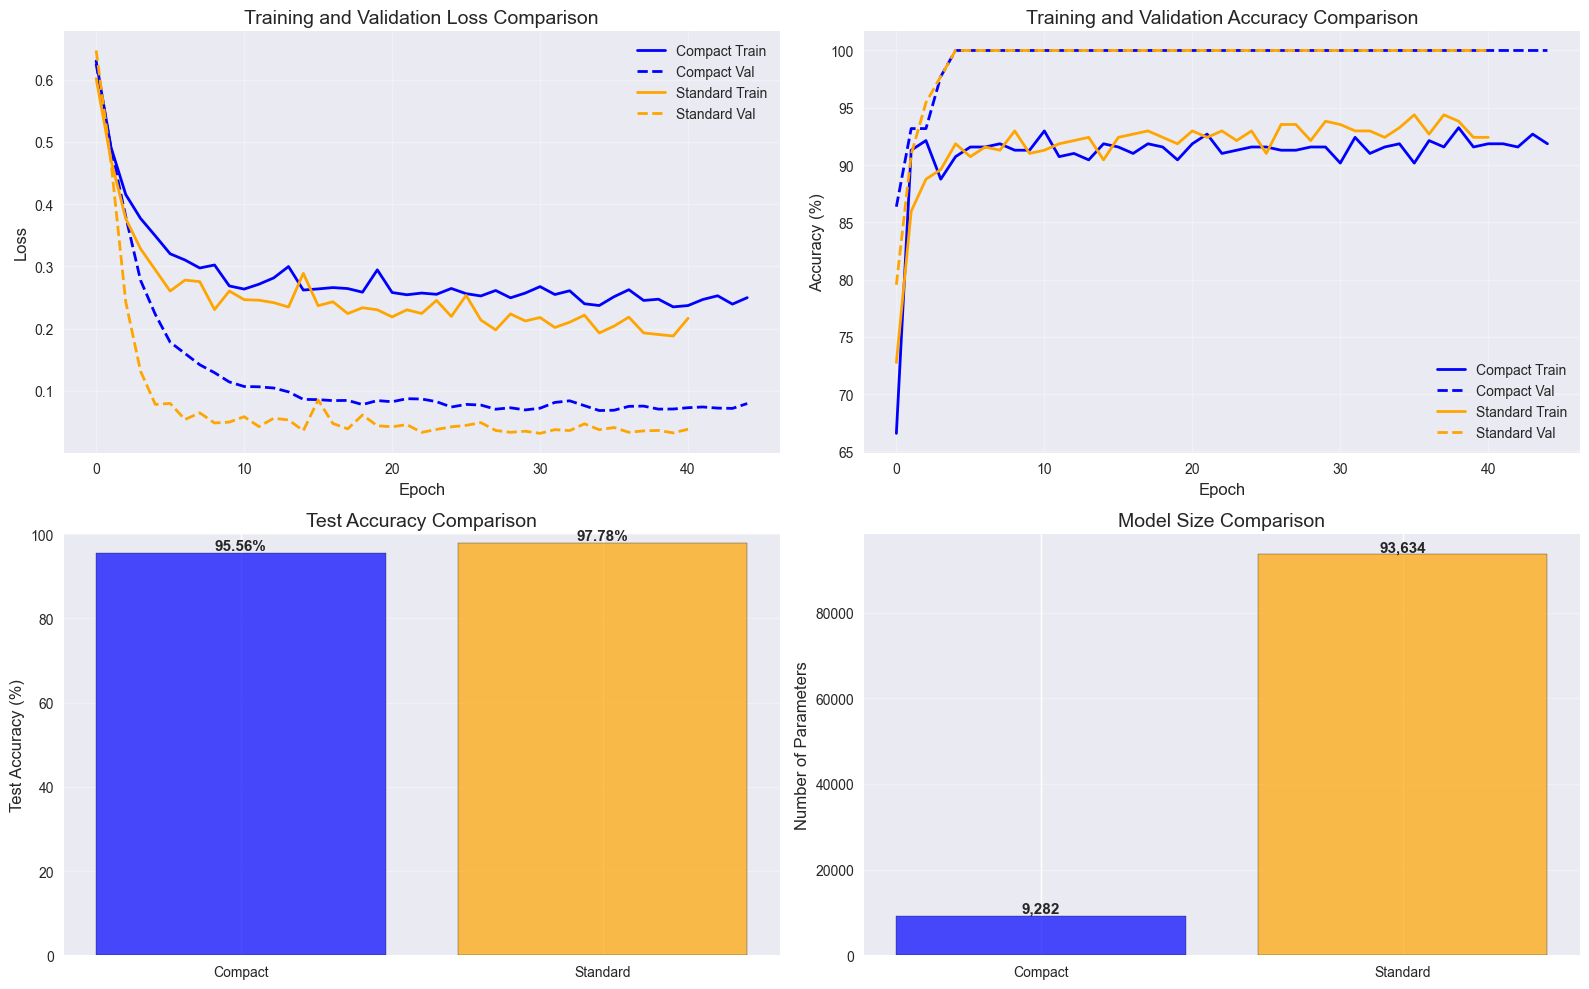


MODEL COMPARISON SUMMARY
Model           Parameters      Test Accuracy   Saved To                      
----------------------------------------------------------------------
Compact         9,282           95.56           seismic_cnn_compact_ak_20260219_102948.pth
Standard        93,634          97.78           seismic_cnn_standard_ak_20260219_103132.pth


In [28]:
# Plot training curves for both models
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = {'compact': 'blue', 'standard': 'orange'}
line_styles = {'train': '-', 'val': '--'}

# Loss comparison
ax = axes[0, 0]
for model_type in models_to_train:
    history = all_results[model_type]['history']
    ax.plot(history['train_loss'], label=f'{model_type.capitalize()} Train', 
            color=colors[model_type], linestyle=line_styles['train'], linewidth=2)
    ax.plot(history['val_loss'], label=f'{model_type.capitalize()} Val', 
            color=colors[model_type], linestyle=line_styles['val'], linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss Comparison', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy comparison
ax = axes[0, 1]
for model_type in models_to_train:
    history = all_results[model_type]['history']
    ax.plot(history['train_acc'], label=f'{model_type.capitalize()} Train', 
            color=colors[model_type], linestyle=line_styles['train'], linewidth=2)
    ax.plot(history['val_acc'], label=f'{model_type.capitalize()} Val', 
            color=colors[model_type], linestyle=line_styles['val'], linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Training and Validation Accuracy Comparison', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Model comparison bar chart - Test Accuracy
ax = axes[1, 0]
model_names = [m.capitalize() for m in models_to_train]
test_accs = [all_results[m]['test_accuracy'] * 100 for m in models_to_train]
params = [all_results[m]['n_params'] for m in models_to_train]

bars = ax.bar(model_names, test_accs, color=[colors[m] for m in models_to_train], alpha=0.7, edgecolor='black')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Test Accuracy Comparison', fontsize=14)
ax.set_ylim([0, 100])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, test_accs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Model comparison - Parameters
ax = axes[1, 1]
bars = ax.bar(model_names, params, color=[colors[m] for m in models_to_train], alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('Model Size Comparison', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, param in zip(bars, params):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{param:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print comparison summary
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(f"{'Model':<15} {'Parameters':<15} {'Test Accuracy':<15} {'Saved To':<30}")
print("-"*70)
for model_type in models_to_train:
    result = all_results[model_type]
    print(f"{model_type.capitalize():<15} {result['n_params']:<15,} {result['test_accuracy']*100:<15.2f} {result['model_path'].name:<30}")
print("="*70)


## Confusion Matrices for Both Models

Compare confusion matrices to see how each model performs on different classes.


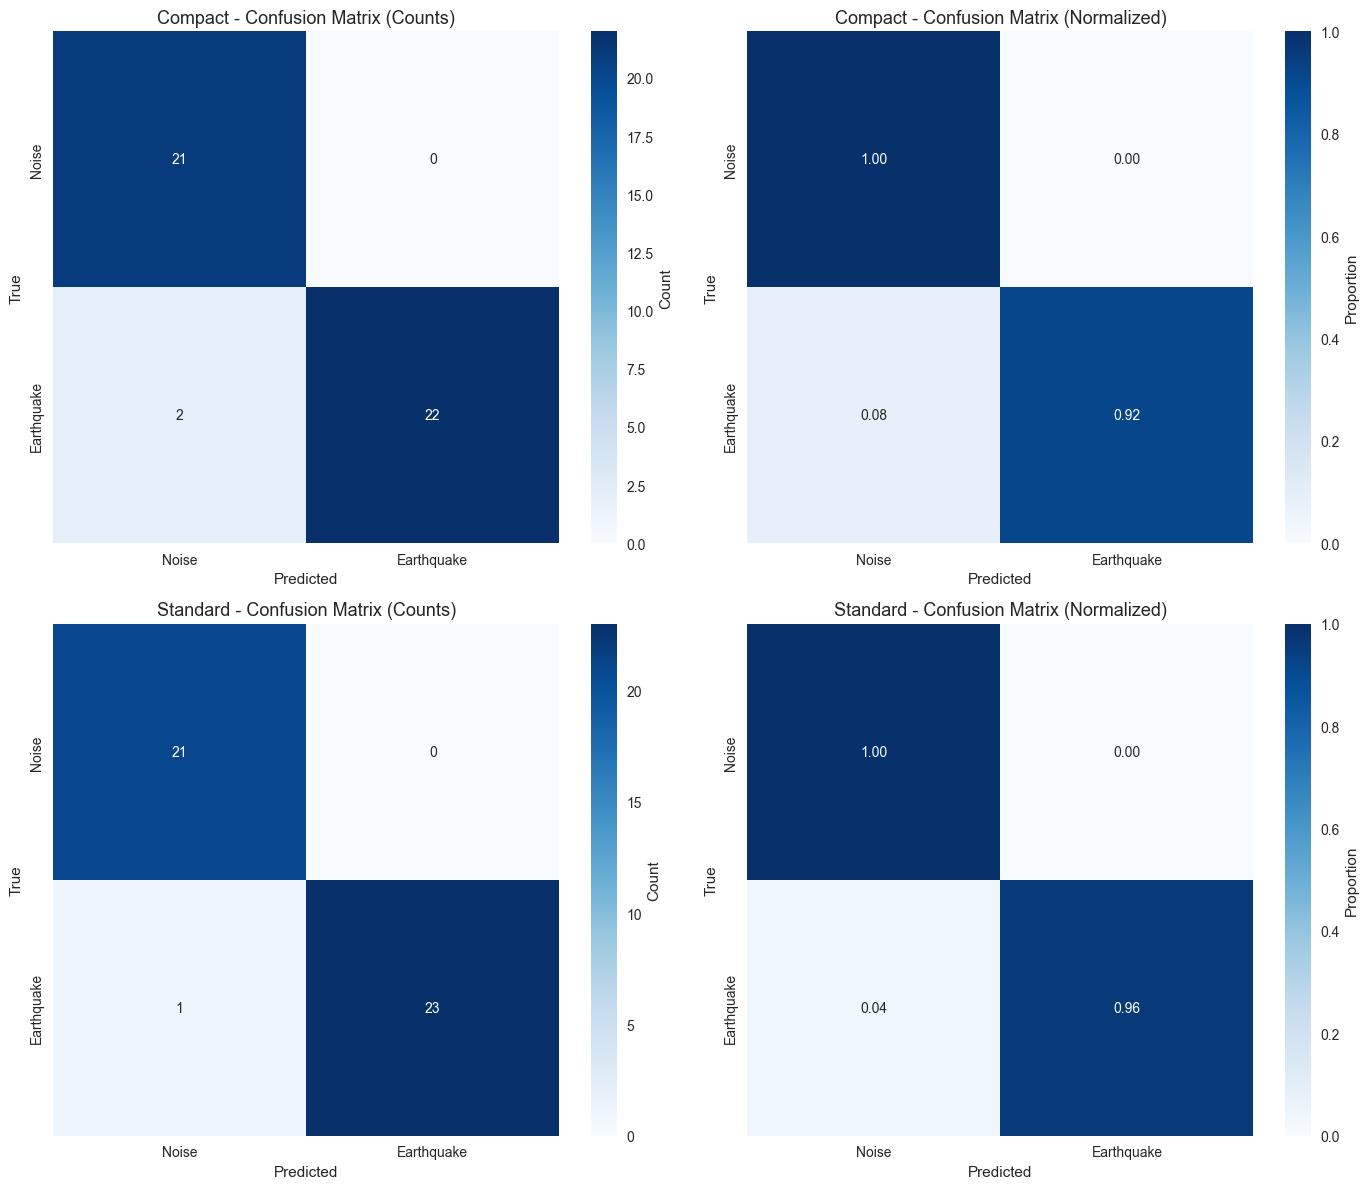

✓ Confusion matrices plotted for both models


In [29]:
# Plot confusion matrices for both models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, model_type in enumerate(models_to_train):
    y_true = all_results[model_type]['y_true']
    y_pred = all_results[model_type]['y_pred']
    
    # Compute confusion matrices
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Raw counts
    ax = axes[idx, 0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
                yticklabels=class_names, ax=ax, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(f'{model_type.capitalize()} - Confusion Matrix (Counts)', fontsize=13)
    
    # Normalized
    ax = axes[idx, 1]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, ax=ax, cbar_kws={'label': 'Proportion'})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(f'{model_type.capitalize()} - Confusion Matrix (Normalized)', fontsize=13)

plt.tight_layout()
plt.show()

print("✓ Confusion matrices plotted for both models")


## Example Predictions

Visualize predictions from the compact model on test examples.


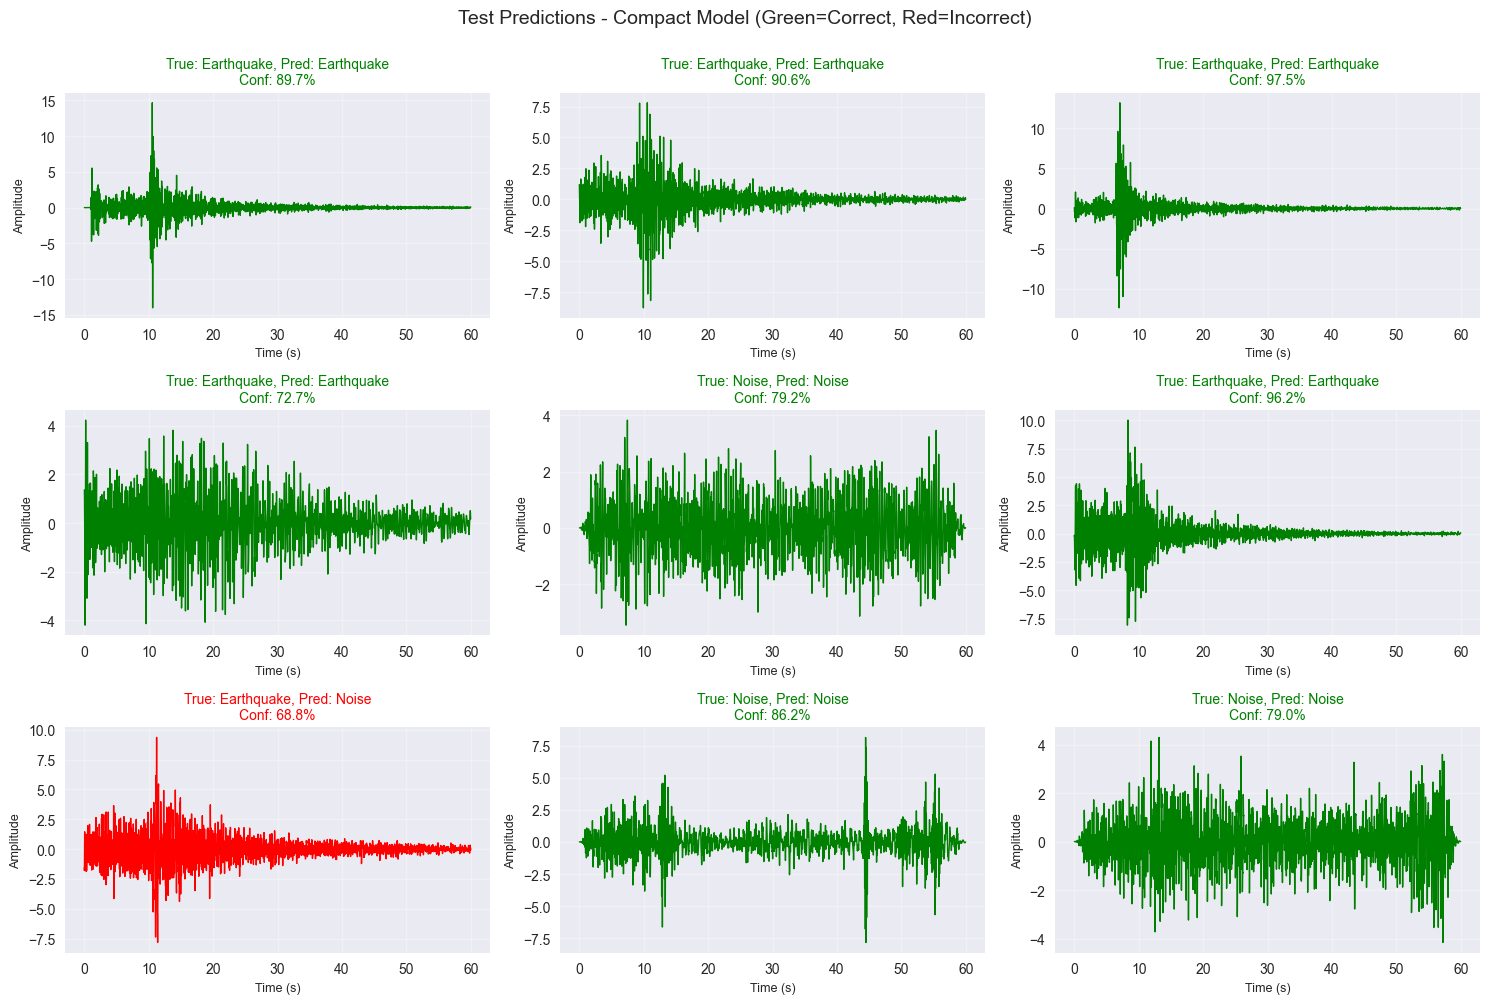

✓ Example predictions visualized


In [30]:
# Use compact model for visualization
model_type = 'compact'
y_pred = all_results[model_type]['y_pred']
y_proba = all_results[model_type]['y_proba']

# Select random examples from test set
n_examples = 9
random_indices = np.random.choice(len(X_test), n_examples, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    ax = axes[i]
    
    # Get waveform
    waveform = X_test[idx, 0, :]  # Remove channel dimension
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    proba = y_proba[idx]
    
    # Plot waveform
    time_axis = np.arange(len(waveform)) / 100.0  # Assuming 100 Hz
    color = 'green' if true_label == pred_label else 'red'
    ax.plot(time_axis, waveform, color=color, linewidth=1)
    
    # Title with prediction info
    title = f"True: {class_names[true_label]}, Pred: {class_names[pred_label]}\n"
    title += f"Conf: {proba[pred_label]*100:.1f}%"
    ax.set_title(title, fontsize=10, color=color)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Test Predictions - {model_type.capitalize()} Model (Green=Correct, Red=Incorrect)', 
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("✓ Example predictions visualized")


## Training Summary

Both models have been saved. Review the final summary.


In [31]:
# Print final summary
print("="*70)
print("TRAINING COMPLETE - FINAL SUMMARY")
print("="*70)

for model_type in models_to_train:
    result = all_results[model_type]
    print(f"\n{model_type.upper()} MODEL:")
    print(f"  Parameters: {result['n_params']:,}")
    print(f"  Test Accuracy: {result['test_accuracy']*100:.2f}%")
    print(f"  Saved to: {result['model_path']}")
    
    # Save training summary
    timestamp = result['model_path'].stem.split('_')[-1]
    summary_file = models_dir / f"training_summary_{model_type}_{timestamp}.txt"
    
    with open(summary_file, 'w') as f:
        f.write(f"Seismic CNN Training Summary - {model_type.upper()} Model\n")
        f.write("="*60 + "\n\n")
        f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write("Model Configuration:\n")
        f.write(f"  Type: {model_type}\n")
        f.write(f"  Parameters: {result['n_params']:,}\n")
        f.write(f"  Input shape: (batch, {input_channels}, {input_length})\n")
        f.write(f"  Number of classes: {num_classes}\n\n")
        
        f.write("Training Configuration:\n")
        f.write(f"  Epochs: {num_epochs}\n")
        f.write(f"  Batch size: {batch_size}\n")
        f.write(f"  Learning rate: {learning_rate}\n")
        f.write(f"  Weight decay: {weight_decay}\n\n")
        
        f.write("Dataset Split:\n")
        f.write(f"  Train: {len(X_train)} samples\n")
        f.write(f"  Validation: {len(X_val)} samples\n")
        f.write(f"  Test: {len(X_test)} samples\n\n")
        
        history = result['history']
        f.write("Results:\n")
        f.write(f"  Best validation loss: {min(history['val_loss']):.4f}\n")
        f.write(f"  Final train accuracy: {history['train_acc'][-1]:.2f}%\n")
        f.write(f"  Final val accuracy: {history['val_acc'][-1]:.2f}%\n")
        f.write(f"  Test accuracy: {result['test_accuracy']*100:.2f}%\n\n")
        
        f.write("Classification Report:\n")
        f.write(classification_report(result['y_true'], result['y_pred'], 
                                     target_names=class_names, digits=3))
    
    print(f"  Summary saved to: {summary_file}")

print("\n" + "="*70)
print("Both models trained and saved successfully!")
print(f"Models directory: {models_dir}")
print("="*70)


TRAINING COMPLETE - FINAL SUMMARY

COMPACT MODEL:
  Parameters: 9,282
  Test Accuracy: 95.56%
  Saved to: ../../models/seismic_cnn_compact_ak_20260219_102948.pth


NameError: name 'learning_rate' is not defined